In [40]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import transforms as T
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Path to dataset files: /kaggle/input/new-plant-diseases-dataset


In [4]:
TRAIN_PATH = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
VALID_PATH = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'

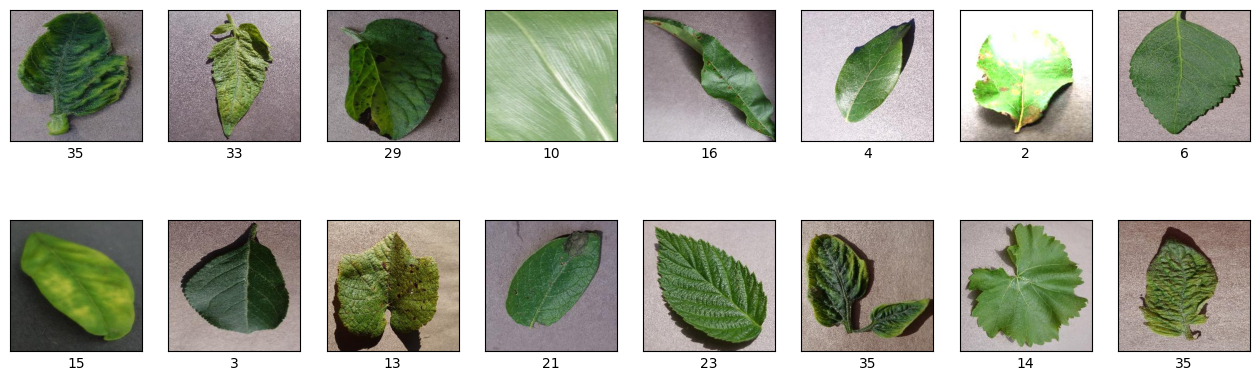

In [5]:
train_set = datasets.ImageFolder(TRAIN_PATH)

cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols, 2.5 * rows))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(train_set))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid(False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(train_set[random_index][0])
        ax.set_xlabel(train_set[random_index][1])
plt.show()

In [6]:
tfms = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

In [7]:
train_set = datasets.ImageFolder(TRAIN_PATH, transform = tfms)
val_set = datasets.ImageFolder(VALID_PATH, transform = tfms)

In [46]:
n = len(train_set)
train_size = int(0.8 * n)
test_size = n - train_size
train_set, test_set = random_split(train_set, [train_size, test_size], generator=torch.Generator().manual_seed(42))

In [8]:
train_set[1]

(tensor([[[ 0.0275,  0.0196,  0.0275,  ..., -0.0275, -0.0431, -0.0510],
          [ 0.0275,  0.0510,  0.0196,  ..., -0.0275, -0.0431, -0.0353],
          [ 0.0275,  0.0196,  0.0039,  ..., -0.0275, -0.0431, -0.0275],
          ...,
          [-0.6000, -0.6000, -0.5922,  ..., -0.3255, -0.3020, -0.2863],
          [-0.6078, -0.6157, -0.6157,  ..., -0.3333, -0.3098, -0.3020],
          [-0.6471, -0.6471, -0.6549,  ..., -0.3333, -0.3176, -0.3098]],
 
         [[-0.0275, -0.0353, -0.0275,  ..., -0.0667, -0.0824, -0.0902],
          [-0.0275, -0.0039, -0.0353,  ..., -0.0667, -0.0824, -0.0745],
          [-0.0275, -0.0353, -0.0510,  ..., -0.0667, -0.0824, -0.0667],
          ...,
          [-0.7333, -0.7255, -0.7255,  ..., -0.3882, -0.3647, -0.3490],
          [-0.7333, -0.7412, -0.7412,  ..., -0.3961, -0.3725, -0.3569],
          [-0.7647, -0.7647, -0.7725,  ..., -0.3882, -0.3804, -0.3647]],
 
         [[ 0.3725,  0.3647,  0.3725,  ...,  0.3725,  0.3569,  0.3490],
          [ 0.3725,  0.3961,

In [47]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=1024, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=1024, shuffle=False, num_workers=2)

In [10]:
class MyNN(nn.Module):
  def __init__(self, n_output, chanels):
    super().__init__()
    self.chanels = chanels
    self.n_output = n_output

    self.conv = nn.Sequential(
        nn.Conv2d(self.chanels, 10, (5, 5), stride=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(10, 20, (3, 3)),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(20, 40, (3, 3)),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(40, 60, (3, 3)),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(60, 80, (3, 3)),
        nn.ReLU(),
        nn.MaxPool2d(2),
    )
    self.classifier = nn.Sequential(
        nn.Linear(320, 160),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(160, 80),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(80, self.n_output)
    )

  def forward(self, X):
    out = self.conv(X)
    out = nn.Flatten()(out)
    out = self.classifier(out)
    return out


In [11]:
def weith_init(model):
  for m in model.modules():
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
      nn.init.kaiming_normal_(m.weight, nonlinearity='relu')


In [12]:
def train_epoch(model, opt, lossfunc):
  model.train()
  loss_list = []
  metric_list = []
  for x_batch, y_batch in train_loader:
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)
    opt.zero_grad()
    pred = model(x_batch)
    loss = lossfunc(pred, y_batch)
    loss.backward()
    opt.step()

    loss_list.append(loss.item())
    metric_value = (torch.argmax(pred, dim=1) == y_batch).float().mean()
    metric_list.append(metric_value.item())
  return loss_list, metric_list


In [13]:
def validation(model, lossfunc):
  model.eval()
  loss_list = []
  metric_list = []

  for x_batch, y_batch in val_loader:
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)
    with torch.no_grad():
      pred = model(x_batch)
      loss = lossfunc(pred, y_batch)
      metric_value = (torch.argmax(pred, dim=1) == y_batch).float().mean()
    loss_list.append(loss.item())
    metric_list.append(metric_value.item())

  return loss_list, metric_list

In [14]:
def train(epoch_num, model, opt, lossfunc, scheduler=None):
  train_loss_list, val_loss_list = [], []
  train_metric_list, val_metric_list = [], []
  for epoch in range(epoch_num):
    loss_train, metric_train = train_epoch(model, opt, lossfunc)
    train_loss_list.append(np.mean(loss_train))
    train_metric_list.append(np.mean(metric_train))

    loss_val, metric_val = validation(model, lossfunc)
    val_loss_list.append(np.mean(loss_val))
    val_metric_list.append(np.mean(metric_val))

    if scheduler is not None:
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(np.mean(loss_val))
        else:
            scheduler.step()

    print(
        f"Epoch {epoch+1}/{epoch_num} | "
        f"train_loss={sum(loss_train)/len(loss_train):.4f} | "
        f"train_acc={sum(metric_train)/len(metric_train):.4f} | "
        f"val_loss={sum(loss_val)/len(loss_val):.4f} | "
        f"val_acc={sum(metric_val)/len(metric_val):.4f}"
    )

  return {
      "train_loss": train_loss_list,
      "val_loss": val_loss_list,
      "train_metric": train_metric_list,
      "val_metric": val_metric_list
  }



In [15]:
num_epochs = 5

model = MyNN(38, 3).to(device)
weith_init(model)
lossfunc = nn.CrossEntropyLoss()
opt = torch.optim.AdamW(model.parameters())
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, num_epochs)

result = train(num_epochs, model, opt, lossfunc, scheduler)

Epoch 1/5 | train_loss=2.0748 | train_acc=0.3977 | val_loss=0.8736 | val_acc=0.7247
Epoch 2/5 | train_loss=0.9408 | train_acc=0.7110 | val_loss=0.4996 | val_acc=0.8440
Epoch 3/5 | train_loss=0.6041 | train_acc=0.8136 | val_loss=0.3800 | val_acc=0.8756
Epoch 4/5 | train_loss=0.4370 | train_acc=0.8631 | val_loss=0.3110 | val_acc=0.9011
Epoch 5/5 | train_loss=0.3447 | train_acc=0.8911 | val_loss=0.2539 | val_acc=0.9192


In [51]:
def train_plot(result):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    axs[0].plot(result["train_loss"], label="train")
    axs[0].plot(result["val_loss"], label="val")
    axs[0].set_xlabel("epoch")
    axs[0].set_ylabel("loss")
    axs[0].legend()

    axs[1].plot(result["train_metric"], label="train")
    axs[1].plot(result["val_metric"], label="val")
    axs[1].set_xlabel("epoch")
    axs[1].set_ylabel("accuracy")
    axs[1].legend()

    plt.show()


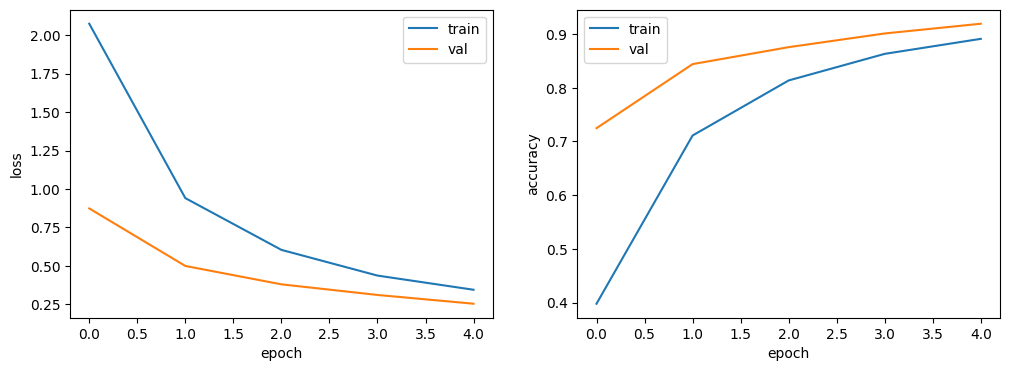

In [52]:
train_plot(result)

In [17]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

In [18]:
def evaluate(model, dataloader, class_names=None):
  preds = []
  y_true = []
  for x_batch, y_batch in dataloader:
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)
    with torch.no_grad():
      pred = torch.argmax(model(x_batch), dim=1)
      preds.extend(pred.cpu())
      y_true.extend(y_batch.cpu())

  acc = accuracy_score(y_true, preds)
  f1 = f1_score(y_true, preds, average="macro")
  cm = confusion_matrix(y_true, preds)

  if class_names is not None:
    report = classification_report(y_true, preds, target_names=class_names)
  else:
      report = classification_report(y_true, preds)

  return {
    "accuracy": acc,
    "macro_f1": f1,
    "confusion_matrix": cm,
    "classification_report": report
  }

In [48]:
evaluate_result = evaluate(model, test_loader, test_set.classes)

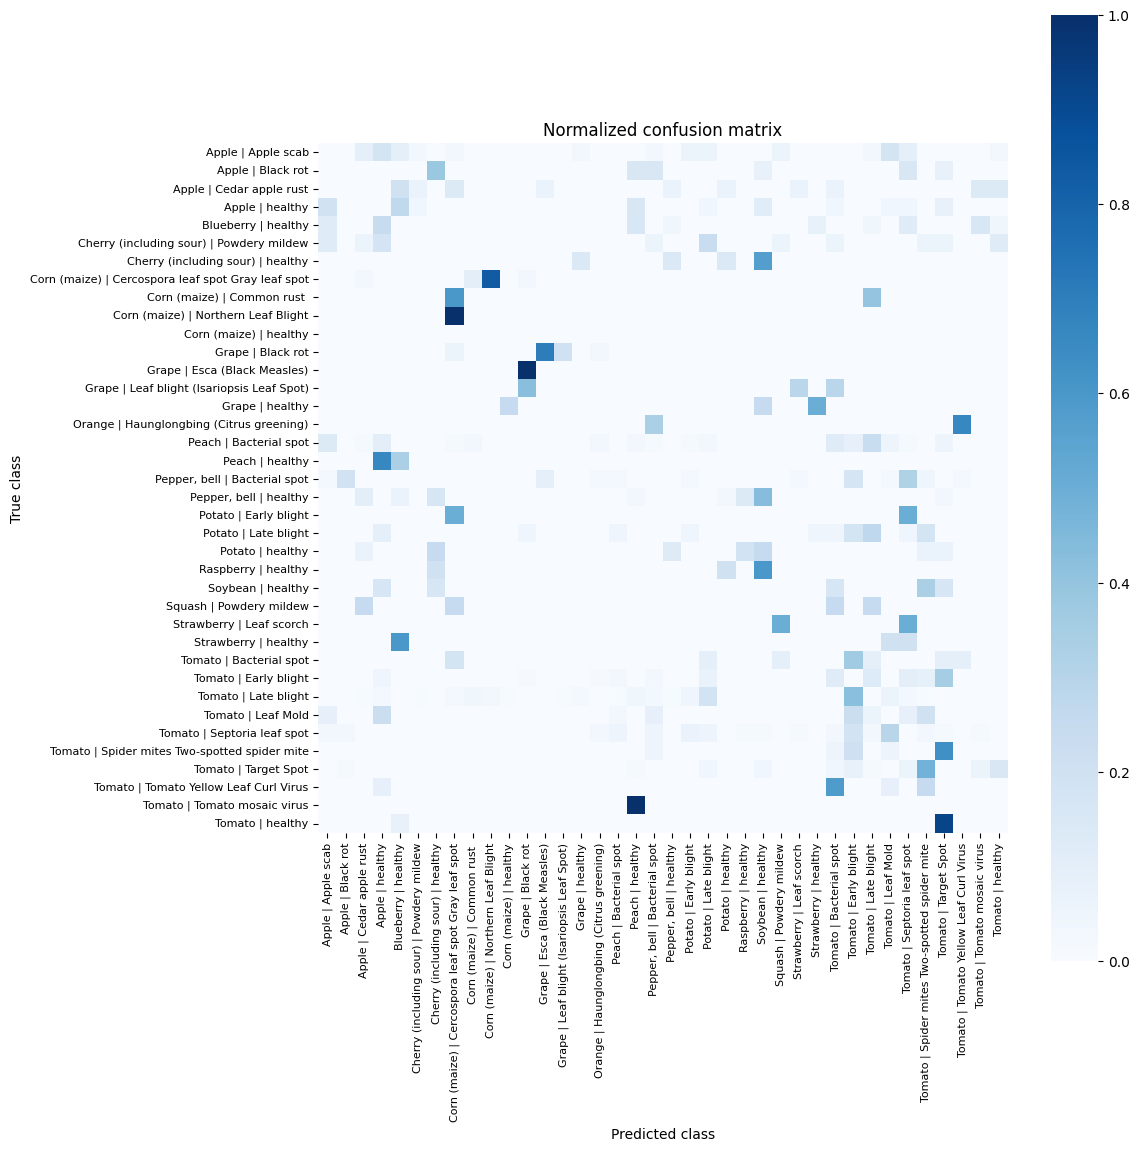

In [49]:
cm = evaluate_result["confusion_matrix"].astype(float)
np.fill_diagonal(cm, 0)
row_sums = cm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm = cm / row_sums

short_names = [name.replace("___", " | ").replace("_", " ") for name in val_set.classes]

plt.figure(figsize=(12, 12))
sns.heatmap(
    cm_norm,
    cmap="Blues",
    xticklabels=short_names,
    yticklabels=short_names,
    square=True,
    cbar=True
)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Normalized confusion matrix")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [35]:
from PIL import Image

def predict_one_image(model, path, transform, classes, top_k):
    model.eval()
    img = Image.open(path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(x)
        probs = torch.softmax(pred, dim=1)
        topprobs, topinds = torch.topk(probs, k=top_k, dim=1)
    topprobs = topprobs[0]
    topinds = topinds[0]

    res = []
    for p, i in zip(topprobs, topinds):
        res.append({
            "proba": p.item(),
            "class": classes[i]
        })
    return res


In [36]:
path = "/kaggle/input/new-plant-diseases-dataset/test/test/AppleCedarRust1.JPG"

In [37]:
predict_one_image(model, path, tfms, train_set.classes, 3)

[{'proba': 0.9500091075897217, 'class': 'Apple___Cedar_apple_rust'},
 {'proba': 0.018113456666469574, 'class': 'Blueberry___healthy'},
 {'proba': 0.0060930452309548855, 'class': 'Peach___healthy'}]

In [53]:
from torchvision import models
from torch.utils.data import DataLoader

In [54]:
tfms_resnet_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]),
])

tfms_resnet = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]),
])

train_set = datasets.ImageFolder(TRAIN_PATH, transform=tfms_resnet_train)
val_set= datasets.ImageFolder(VALID_PATH, transform=tfms_resnet)

n = len(train_set)
train_size = int(0.8 * n)
test_size = n - train_size
train_set, test_set = random_split(train_set, [train_size, test_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=1024, shuffle=False, num_workers=2)
test_loader = DataLoader(train_set, batch_size=1024, shuffle=False, num_workers=2)

In [55]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 38)
model = model.to(device)

for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

lossfunc = nn.CrossEntropyLoss()
opt = optim.AdamW(model.fc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=5)

result_stage1 = train(5, model, opt, lossfunc, scheduler=None)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 140MB/s]


Epoch 1/5 | train_loss=0.6301 | train_acc=0.8688 | val_loss=0.2477 | val_acc=0.9365
Epoch 2/5 | train_loss=0.2129 | train_acc=0.9438 | val_loss=0.1749 | val_acc=0.9523
Epoch 3/5 | train_loss=0.1634 | train_acc=0.9552 | val_loss=0.1493 | val_acc=0.9575
Epoch 4/5 | train_loss=0.1398 | train_acc=0.9617 | val_loss=0.1425 | val_acc=0.9582
Epoch 5/5 | train_loss=0.1285 | train_acc=0.9652 | val_loss=0.1354 | val_acc=0.9617


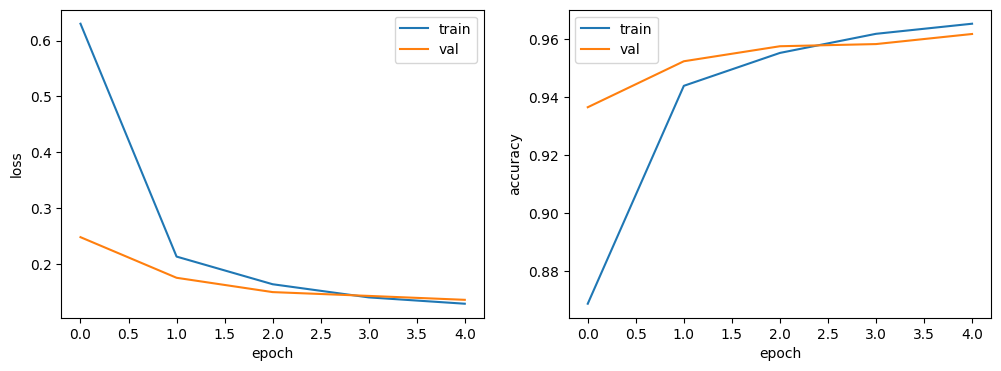

In [56]:
train_plot(result_stage1)

In [57]:
for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

opt = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=5)

result_stage2 = train(5, model, opt, lossfunc, scheduler=None)

Epoch 1/5 | train_loss=0.0689 | train_acc=0.9777 | val_loss=0.0345 | val_acc=0.9892
Epoch 2/5 | train_loss=0.0111 | train_acc=0.9968 | val_loss=0.0287 | val_acc=0.9909
Epoch 3/5 | train_loss=0.0052 | train_acc=0.9986 | val_loss=0.0247 | val_acc=0.9920
Epoch 4/5 | train_loss=0.0069 | train_acc=0.9981 | val_loss=0.0381 | val_acc=0.9881
Epoch 5/5 | train_loss=0.0101 | train_acc=0.9971 | val_loss=0.0289 | val_acc=0.9916


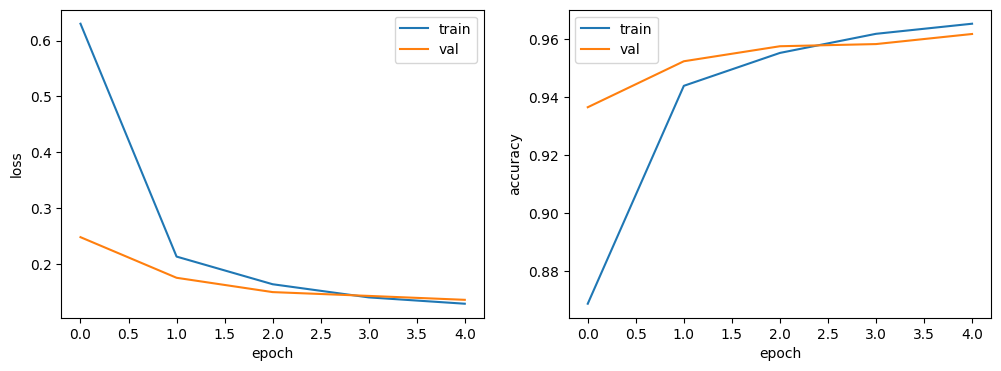

In [58]:
train_plot(result_stage1)